# GAE
이 튜토리얼은 **GAE (Generalized Advantage Estimation)**를 적용한 PPO 알고리즘을 구현하는 방법을 안내한다.

**GAE (Generalized Advantage Estimation)**는 강화학습에서 **Advantage(어드밴티지)** 함수를 추정할 때 발생하는 **편향(Bias)**과 **분산(Variance)**의 트레이드오프를 조절하는 기법이다.  (Lambda) 파라미터를 사용하여 TD(0)와 Monte-Carlo 사이의 균형을 맞춘다. 이를 통해 학습의 안정성과 속도를 모두 향상시킬 수 있다.

이 튜토리얼에서는 최신 라이브러리인 `gymnasium`과 `torch`를 사용하여 구현하며, 환경은 연속적인 행동 공간을 가진 `LunarLanderContinuous-v2`를 사용한다.

### 1. 가상 디스플레이 설정 (Setup virtual display)

강화학습 환경의 렌더링을 위해 가상 디스플레이를 설정한다.

In [ ]:
# 최신 파이썬 라이브러리 설치
%pip install gymnasium[box2d] pyvirtualdisplay torch numpy matplotlib imageio

In [1]:
from pyvirtualdisplay import Display

# 가상 디스플레이 시작
virtual_display = Display(visible=False, size=(1400, 900))
virtual_display.start()

### 2. 라이브러리 임포트 (Import libraries)

학습에 필요한 라이브러리를 불러온다.

In [2]:
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Normal
from collections import deque
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import HTML
from base64 import b64encode
import imageio

# GPU 사용 가능 여부 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 장치: {device}")

사용 장치: cuda


### 3. 비디오 출력 함수 (Display Video)

학습 결과를 영상으로 확인하기 위한 함수다.

In [3]:
def display_video(video_path):
    """
    저장된 mp4 비디오 파일을 읽어 HTML 태그로 변환하여 출력한다.
    """
    mp4 = open(video_path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    return HTML("""
    <video width=400 controls>
          <source src="%s" type="video/mp4">
    </video>
    """ % data_url)

### 4. Actor & Critic 네트워크 생성 (Create Actor & Critic Networks)

PPO와 GAE를 구현하기 위해서는 정책(Actor)과 가치 함수(Critic)가 필요하다.
가중치 초기화는 학습 안정성에 큰 영향을 미치므로 **직교 초기화(Orthogonal Initialization)**를 적용한다.

In [4]:
def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    """레이어 초기화 함수 (Orthogonal Initialization)"""
    torch.nn.init.orthogonal_(layer.weight, std)
    torch.nn.init.constant_(layer.bias, bias_const)
    return layer

class Actor(nn.Module):
    def __init__(self, obs_size, hidden_size, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            layer_init(nn.Linear(obs_size, hidden_size)),
            nn.Tanh(),
            layer_init(nn.Linear(hidden_size, hidden_size)),
            nn.Tanh(),
        )
        self.mean_layer = layer_init(nn.Linear(hidden_size, action_dim), std=0.01)
        self.log_std = nn.Parameter(torch.zeros(1, action_dim)) # 학습 가능한 파라미터

    def forward(self, x):
        x = self.net(x)
        mean = self.mean_layer(x)
        std = self.log_std.exp().expand_as(mean)
        return mean, std

class Critic(nn.Module):
    def __init__(self, obs_size, hidden_size):
        super().__init__()
        self.net = nn.Sequential(
            layer_init(nn.Linear(obs_size, hidden_size)),
            nn.Tanh(),
            layer_init(nn.Linear(hidden_size, hidden_size)),
            nn.Tanh(),
            layer_init(nn.Linear(hidden_size, 1), std=1.0)
        )

    def forward(self, x):
        return self.net(x)

### 5. Pytorch Wrapper 클래스 (GAE 및 PPO 구현)

이 클래스에 GAE 계산 로직과 PPO 학습 로직이 모두 포함된다.
**핵심 부분은 `compute_gae` 메서드다.**

* **GAE 수식**:



여기서  (TD Error)이다.
이면 TD(0)와 같아지고(고편향, 저분산), 이면 Monte-Carlo와 같아진다(저편향, 고분산).

In [5]:
class PytorchWrapper:
    def __init__(self, env_name, hidden_size=64, lr=3e-4,
                 gamma=0.99, gae_lambda=0.95, clip_coef=0.2, ent_coef=0.0,
                 vf_coef=0.5, max_grad_norm=0.5,
                 n_steps=2048, batch_size=64, n_epochs=10):
        self.env_name = env_name
        self.gamma = gamma
        self.gae_lambda = gae_lambda # GAE 파라미터
        self.clip_coef = clip_coef
        self.ent_coef = ent_coef
        self.vf_coef = vf_coef
        self.max_grad_norm = max_grad_norm
        self.n_steps = n_steps
        self.batch_size = batch_size
        self.n_epochs = n_epochs

        # 환경 생성
        self.env = gym.make(env_name, render_mode='rgb_array')
        obs_size = self.env.observation_space.shape[0]
        action_dim = self.env.action_space.shape[0]

        # 네트워크 생성
        self.actor = Actor(obs_size, hidden_size, action_dim).to(device)
        self.critic = Critic(obs_size, hidden_size).to(device)

        # 최적화기
        self.optimizer = optim.AdamW(
            list(self.actor.parameters()) + list(self.critic.parameters()),
            lr=lr, eps=1e-5
        )

    def get_action(self, state):
        """행동 선택 (테스트 용)"""
        state_t = torch.tensor(np.array([state]), dtype=torch.float32, device=device)
        with torch.no_grad():
            mean, _ = self.actor(state_t)
        return mean.cpu().numpy()[0]

    def compute_gae(self, rewards, values, dones, next_value):
        """
        GAE (Generalized Advantage Estimation) 계산
        Advantage = delta + gamma * lambda * next_Advantage
        """
        advantages = torch.zeros_like(rewards).to(device)
        last_gae_lam = 0

        # 역순으로 계산 (미래의 보상이 현재에 영향을 미치므로)
        for t in reversed(range(len(rewards))):
            if t == len(rewards) - 1:
                next_non_terminal = 1.0 - 0.0 # 마지막 스텝 처리 (단일 에피소드 가정 시 0 또는 외부 값)
                next_val = next_value
            else:
                next_non_terminal = 1.0 - dones[t+1]
                next_val = values[t+1]

            # TD Error: delta = r + gamma * V(s') - V(s)
            delta = rewards[t] + self.gamma * next_val * next_non_terminal - values[t]

            # GAE: A = delta + gamma * lambda * A_next
            last_gae_lam = delta + self.gamma * self.gae_lambda * next_non_terminal * last_gae_lam
            advantages[t] = last_gae_lam

        # Returns = Advantage + Value (타겟 가치 함수 학습용)
        returns = advantages + values
        return advantages, returns

    def train_step(self):
        """데이터 수집(Rollout) 후 PPO 업데이트"""

        # 1. 데이터 수집 (Rollout)
        states, actions, log_probs, rewards, dones, values = [], [], [], [], [], []

        state, _ = self.env.reset()
        done = False

        for _ in range(self.n_steps):
            state_t = torch.tensor(np.array([state]), dtype=torch.float32, device=device)

            with torch.no_grad():
                mean, std = self.actor(state_t)
                dist = Normal(mean, std)
                action = dist.sample()
                log_prob = dist.log_prob(action).sum(axis=-1)
                value = self.critic(state_t)

            action_np = action.cpu().numpy()[0]
            next_state, reward, terminated, truncated, _ = self.env.step(action_np)
            done_flag = terminated or truncated

            states.append(state_t)
            actions.append(action)
            log_probs.append(log_prob)
            rewards.append(reward)
            dones.append(done_flag)
            values.append(value)

            state = next_state
            if done_flag:
                state, _ = self.env.reset()

        # 텐서 변환
        states = torch.cat(states)
        actions = torch.cat(actions)
        log_probs = torch.cat(log_probs)
        rewards = torch.tensor(rewards, dtype=torch.float32, device=device)
        dones = torch.tensor(dones, dtype=torch.float32, device=device)
        values = torch.cat(values).squeeze()

        # 마지막 상태 가치 계산 (GAE용)
        with torch.no_grad():
            next_state_t = torch.tensor(np.array([state]), dtype=torch.float32, device=device)
            next_value = self.critic(next_state_t).squeeze()

        # 2. GAE 계산 (이 챕터의 핵심)
        advantages, returns = self.compute_gae(rewards, values, dones, next_value)

        # Flatten
        b_states = states
        b_actions = actions
        b_log_probs = log_probs
        b_advantages = advantages
        b_returns = returns
        b_values = values

        # 3. PPO 업데이트 (Epoch 반복)
        indices = np.arange(self.n_steps)

        for _ in range(self.n_epochs):
            np.random.shuffle(indices)

            for start in range(0, self.n_steps, self.batch_size):
                end = start + self.batch_size
                idx = indices[start:end]

                mb_states = b_states[idx]
                mb_actions = b_actions[idx]
                mb_old_log_probs = b_log_probs[idx]
                mb_advantages = b_advantages[idx]
                mb_returns = b_returns[idx]

                # Advantage 정규화 (학습 안정성)
                mb_advantages = (mb_advantages - mb_advantages.mean()) / (mb_advantages.std() + 1e-8)

                # 현재 정책 평가
                mean, std = self.actor(mb_states)
                dist = Normal(mean, std)
                new_log_probs = dist.log_prob(mb_actions).sum(axis=-1)
                entropy = dist.entropy().sum(axis=-1)
                new_values = self.critic(mb_states).squeeze()

                # Ratio 계산
                log_ratio = new_log_probs - mb_old_log_probs
                ratio = log_ratio.exp()

                # Surrogate Loss (PPO Clipped Objective)
                pg_loss1 = -mb_advantages * ratio
                pg_loss2 = -mb_advantages * torch.clamp(ratio, 1 - self.clip_coef, 1 + self.clip_coef)
                pg_loss = torch.max(pg_loss1, pg_loss2).mean()

                # Value Loss
                v_loss = 0.5 * ((new_values - mb_returns) ** 2).mean()

                # Total Loss
                loss = pg_loss - self.ent_coef * entropy.mean() + self.vf_coef * v_loss

                self.optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(list(self.actor.parameters()) + list(self.critic.parameters()), self.max_grad_norm)
                self.optimizer.step()

        return b_returns.mean().item()

    def run_training(self, max_timesteps=200000):
        total_steps = 0
        rewards_history = []

        while total_steps < max_timesteps:
            mean_return = self.train_step()
            total_steps += self.n_steps
            rewards_history.append(mean_return)

            if total_steps % (self.n_steps * 5) == 0:
                print(f"Steps: {total_steps}, Mean Return: {mean_return:.2f}")

        return rewards_history

    def save_video(self, filename="gae_video"):
        env = gym.make(self.env_name, render_mode='rgb_array')
        env = gym.wrappers.RecordVideo(env, video_folder="videos", name_prefix=filename)

        state, _ = env.reset()
        done = False

        while not done:
            action = self.get_action(state)
            state, _, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
        env.close()

### 6. 학습 실행 (Training)

GAE가 적용된 PPO 에이전트를 생성하고 학습을 시작한다. GAE Lambda 값(`0.95`)이 Advantage 계산에 사용된다.

In [7]:
# GAE + PPO 모델 생성
agent = PytorchWrapper(
    'LunarLanderContinuous-v3',
    hidden_size=128,
    lr=3e-4,
    gamma=0.99,
    gae_lambda=0.95, # GAE Lambda 설정
    n_steps=2048,
    batch_size=64,
    n_epochs=10
)

# 학습 시작
print("GAE (Generalized Advantage Estimation) PPO 학습을 시작한다...")
history = agent.run_training(max_timesteps=300000)
print("학습 완료.")

/home/kubwa/anaconda3/envs/RL/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


GAE (Generalized Advantage Estimation) PPO 학습을 시작한다...
Steps: 10240, Mean Return: -7.37
Steps: 20480, Mean Return: 22.68
Steps: 30720, Mean Return: 12.77
Steps: 40960, Mean Return: 3.43
Steps: 51200, Mean Return: 8.77
Steps: 61440, Mean Return: 8.18
Steps: 71680, Mean Return: 12.51
Steps: 81920, Mean Return: 9.10
Steps: 92160, Mean Return: 9.13
Steps: 102400, Mean Return: 8.23
Steps: 112640, Mean Return: 10.09
Steps: 122880, Mean Return: 10.75
Steps: 133120, Mean Return: 8.09
Steps: 143360, Mean Return: 7.52
Steps: 153600, Mean Return: 11.51
Steps: 163840, Mean Return: 15.30
Steps: 174080, Mean Return: 8.87
Steps: 184320, Mean Return: 2.85
Steps: 194560, Mean Return: 3.79
Steps: 204800, Mean Return: 10.22
Steps: 215040, Mean Return: 13.68
Steps: 225280, Mean Return: 22.41
Steps: 235520, Mean Return: 13.71
Steps: 245760, Mean Return: 3.02
Steps: 256000, Mean Return: 19.84
Steps: 266240, Mean Return: 5.21
Steps: 276480, Mean Return: 13.01
Steps: 286720, Mean Return: 17.80
Steps: 296960, 

### 7. 결과 시각화 (Visualization)

학습 결과를 그래프와 비디오로 확인한다.

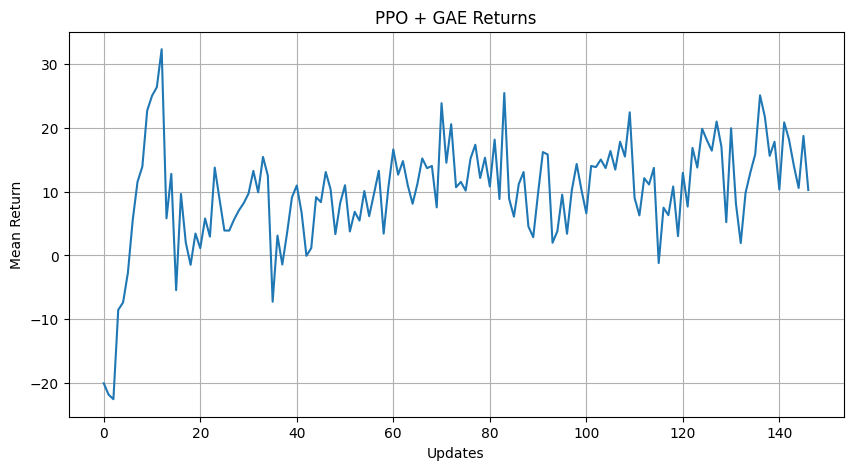

/home/kubwa/anaconda3/envs/RL/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/kubwa/02-Deep-RL/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [8]:
# 학습 곡선
plt.figure(figsize=(10, 5))
plt.plot(history)
plt.title("PPO + GAE Returns")
plt.xlabel("Updates")
plt.ylabel("Mean Return")
plt.grid(True)
plt.show()

# 비디오 저장 및 확인
import glob
import os

agent.save_video("gae-ppo")

# 가장 최근 비디오 파일 찾기
video_files = glob.glob("videos/*.mp4")
if video_files:
    latest_video = max(video_files, key=os.path.getctime)
    display(display_video(latest_video))
else:
    print("비디오 파일을 찾을 수 없다.")